In [1]:
from spisea import synthetic, atmospheres, reddening, evolution
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os
import copy
import pandas as pd
from tqdm import tqdm
from filter_extinction import ext_utils
import pdb
from scipy.special import factorial

In [2]:
%load_ext autoreload
%autoreload 2

# Set up the ExtinctionCoefficientFitter
First, the fitter object will generate or load a grid of stellar colors and extinctions

In [3]:
roman_filters = [['roman,wfi,f062', 'roman,wfi,f087', 'roman,wfi,f106', 'roman,wfi,f129',
                  'roman,wfi,f158', 'roman,wfi,f184', 'roman,wfi,f213', 'roman,wfi,f146'],
                 ['euclid,Y', 'euclid,J', 'euclid,H'],
                 ['decam,u', 'decam,g', 'decam,r', 'decam,i', 'decam,z', 'decam,Y'],
                 ['gaia,edr3,G', 'gaia,edr3,Gbp', 'gaia,edr3,Grp'],
                 ['rubin,u', 'rubin,g', 'rubin,r', 'rubin,i', 'rubin,z', 'rubin,y'],
                 ['wfc3,uvis1,f390w', 'wfc3,uvis1,f555w', 'wfc3,uvis1,f606w', 'wfc3,uvis1,f814w',
                  'wfc3,ir,f098m', 'wfc3,ir,f139m', 'wfc3,ir,f153m',
                  'wfc3,ir,f167n', 'wfc3,ir,f130n',
                  'wfc3,ir,f110w', 'wfc3,ir,f160w'],
                 ['jwst,f115w', 'jwst,f140m', 'jwst,f182m', 'jwst,f212n',
                  'jwst,f323n', 'jwst,f360m', 'jwst,f405n', 'jwst,f480m'],
                 ['bessell,U','bessell,B','bessell,V','bessell,R','bessell,I',
                  'jg,J','jg,H','jg,K'],
                 ['ogle,V','ogle,I','ogle,Rw']
                ]
ecf=0
# Compute extinction for all of Roman's filters, and exclude F146 from the color set
# This will use these defaults: A_Ks range of 0-5, [Fe/H]=0.0, and logg=[4.5, 2.0]
# If you change the A_Ks grid spacing, logg values, or filter sets, set recompute=True
ecf = ext_utils.ExtinctionCoefficientFitter(color_filter_list=roman_filters,
                                            ext_only_filter_list = ['euclid,vis'],
                                            #recompute_grid=True,
                                           )

For roman,wfi,f062, m_ab - m_vega = 0.14709092032372728 mag(AB / VEGA)
For roman,wfi,f087, m_ab - m_vega = 0.4965860048596544 mag(AB / VEGA)
For roman,wfi,f106, m_ab - m_vega = 0.6634601723489354 mag(AB / VEGA)
For roman,wfi,f129, m_ab - m_vega = 0.9719886275971806 mag(AB / VEGA)
For roman,wfi,f158, m_ab - m_vega = 1.3044722675728742 mag(AB / VEGA)
For roman,wfi,f184, m_ab - m_vega = 1.5712118181112267 mag(AB / VEGA)
For roman,wfi,f213, m_ab - m_vega = 1.8256634699591512 mag(AB / VEGA)
For roman,wfi,f146, m_ab - m_vega = 1.0364436822930514 mag(AB / VEGA)
For euclid,Y, m_ab - m_vega = 0.6918633897055476 mag(AB / VEGA)
For euclid,J, m_ab - m_vega = 1.0572773144395051 mag(AB / VEGA)
For euclid,H, m_ab - m_vega = 1.4907150155944529 mag(AB / VEGA)
For decam,u, m_ab - m_vega = 0.7702716718456117 mag(AB / VEGA)
For decam,g, m_ab - m_vega = -0.11193100692241523 mag(AB / VEGA)
For decam,r, m_ab - m_vega = 0.18205313135467607 mag(AB / VEGA)
For decam,i, m_ab - m_vega = 0.41940203543605864 mag(AB

In [4]:
ecf.ext_grid

,roman_wfi_f062-roman_wfi_f087,roman_wfi_f062-roman_wfi_f087-abs,roman_wfi_f087-roman_wfi_f106,roman_wfi_f087-roman_wfi_f106-abs,roman_wfi_f106-roman_wfi_f129,roman_wfi_f106-roman_wfi_f129-abs,roman_wfi_f129-roman_wfi_f158,roman_wfi_f129-roman_wfi_f158-abs,roman_wfi_f158-roman_wfi_f184,roman_wfi_f158-roman_wfi_f184-abs,...,ext_jg_J,ext_jg_H,ext_jg_K,ext_ogle_V,ext_ogle_I,ext_ogle_Rw,ext_euclid_vis,Teff,logg,A_Ks
0,25.988254,2.981589,11.994263,1.263392,7.157817,0.381363,5.341732,0.023716,2.167475,-0.026996,...,16.371632,8.969063,4.719499,76.498491,40.541227,29.382094,36.803364,2500,2.0,5.0
1,25.933664,2.926593,11.987199,1.244652,7.161860,0.379299,5.348118,0.032609,2.150621,-0.035064,...,16.369843,8.968982,4.719454,76.491837,40.549613,29.405202,36.828608,2535,2.0,5.0
2,25.886732,2.880357,11.980796,1.227874,7.165535,0.377418,5.353868,0.040669,2.135302,-0.042371,...,16.368204,8.968910,4.719412,76.486714,40.556787,29.425794,36.850667,2571,2.0,5.0
3,25.844397,2.839592,11.974347,1.211995,7.170473,0.375927,5.361358,0.051032,2.119896,-0.049454,...,16.366214,8.968885,4.719496,76.484144,40.563423,29.445050,36.870567,2607,2.0,5.0
4,25.801890,2.799868,11.966106,1.194772,7.181025,0.375455,5.376676,0.071880,2.100673,-0.057438,...,16.362523,8.969017,4.720052,76.487441,40.570774,29.465313,36.889811,2644,2.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.302813,-0.352130,0.110461,-0.170462,-0.109356,-0.298265,-0.207349,-0.329184,-0.208892,-0.275790,...,0.367637,0.191831,0.098909,1.769676,0.975039,0.976627,1.231931,9455,4.5,0.1
9996,0.296142,-0.359600,0.107077,-0.173816,-0.112943,-0.301918,-0.209487,-0.331366,-0.209670,-0.276577,...,0.367686,0.191835,0.098911,1.769985,0.975133,0.976961,1.232766,9589,4.5,0.1
9997,0.289858,-0.366626,0.103678,-0.177191,-0.116310,-0.305349,-0.211481,-0.333399,-0.210466,-0.277382,...,0.367731,0.191839,0.098913,1.770275,0.975216,0.977279,1.233542,9724,4.5,0.1
9998,0.283929,-0.373224,0.100208,-0.180654,-0.119350,-0.308453,-0.213311,-0.335262,-0.211274,-0.278199,...,0.367771,0.191844,0.098915,1.770544,0.975290,0.977587,1.234255,9861,4.5,0.1


# The fitting process
Next, we can use the computed grid to fit extinction in one filter to a polynomial of custom order of A_Ks and selected filter color(s). Polynomial cross terms are used for each color to A_Ks but not among different colors.

For different applications, it may be optimal to use different colors to estimate the extinction in a certain filter. We explore a few options for this.

In [6]:
fits_dict = {}

# Roman
Let's fit the extinction function for each filter. For the bluest and reddest filters, we use the filter and its neighboring filter to use a single color. For middle standard filters, we use two colors, pairing the filter with each neighbor. For the F146 wide filter, we use 3 colors, incorporating all 4 standard filters it encompasses.

The GBTDS includes snapshots in all filters.

This is all we provide for absolute magnitudes, as these are for simulations where one can assume all filters can be simulated.

In [7]:
# Set up which colors to use for which fits
roman_fits = {'f062': ['f062-f087'], 
              'f087': ['f062-f087', 'f087-f106'], 
              'f106': ['f087-f106', 'f106-f129'], 
              'f129': ['f106-f129', 'f129-f158'], 
              'f158': ['f129-f158', 'f158-f184'], 
              #'f184': ['f158-f184', 'f184-f213'], 
              #'f213': ['f184-f213'], 
              'f146': ['f106-f129', 'f129-f158', 'f158-f184']}

## Run fits

roman_wfi_f062 0.014242574519429327
roman_wfi_f087 0.004791384064303797
roman_wfi_f106 0.0025943018481720073
roman_wfi_f129 0.006550456480853085
roman_wfi_f158 0.026512599320658074
roman_wfi_f146 0.008965232804025388


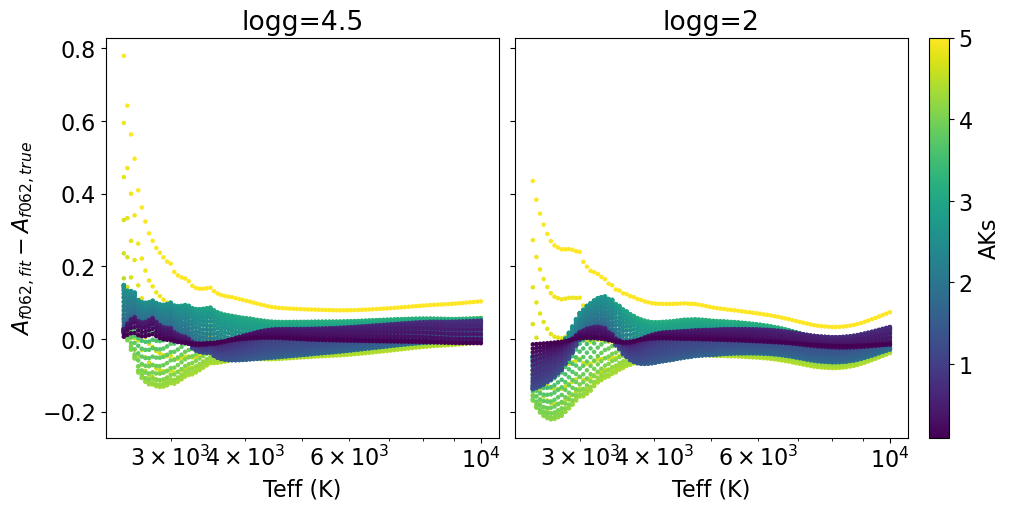

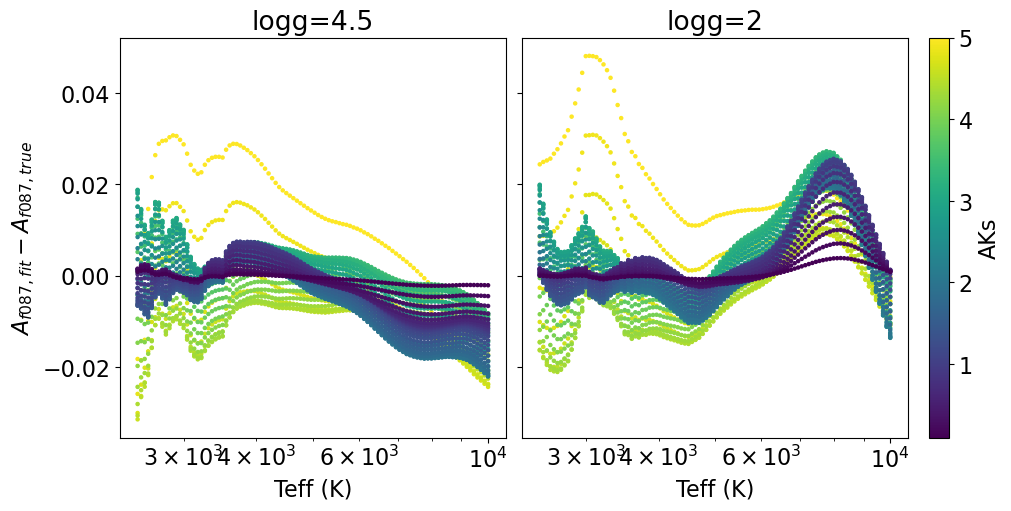

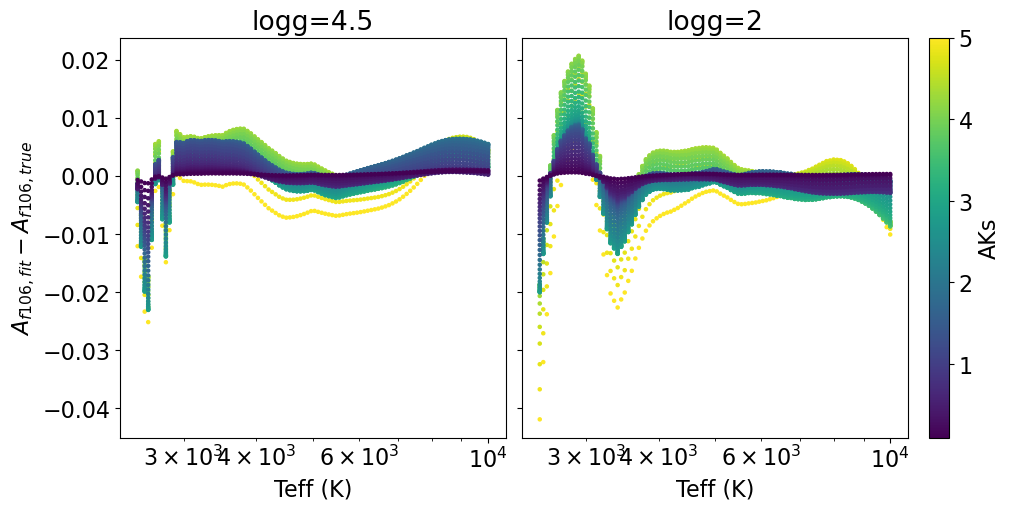

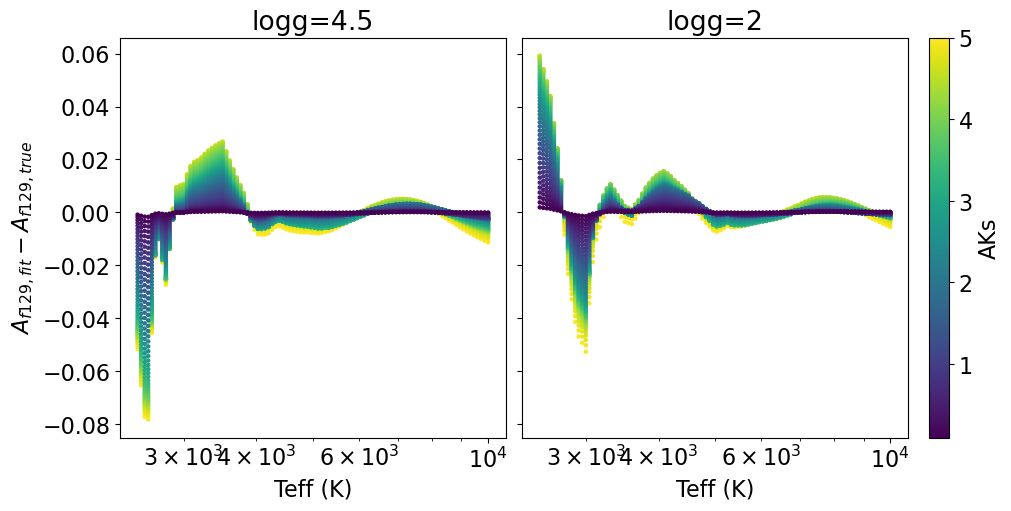

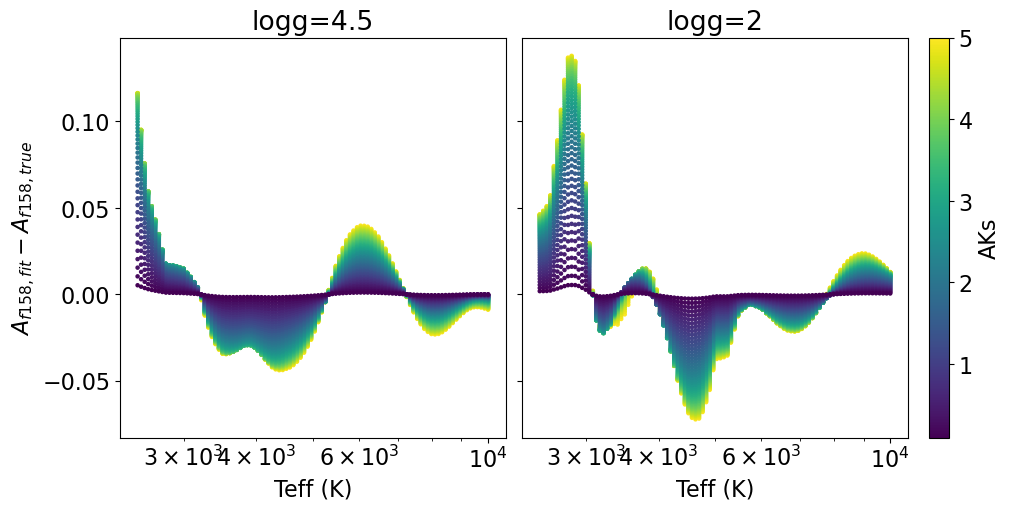

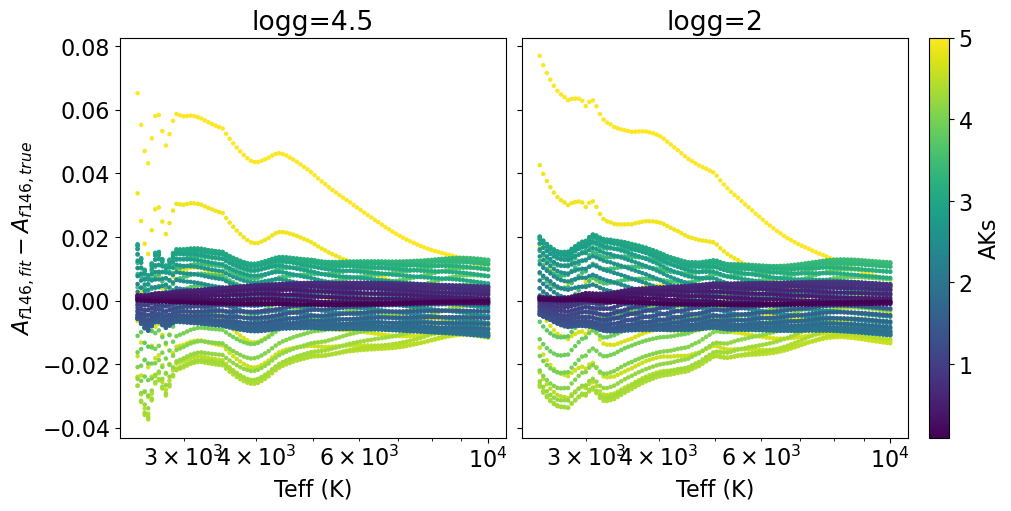

In [8]:
roman_tabs = []
roman_eqs  = []
for k,v in roman_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'roman_wfi_{c1}-roman_wfi_{c2}-abs')
    ecf.run_fit(f'roman_wfi_{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    roman_tabs.append(ecf.print_coeffs_deluxetable())
    roman_eqs.append(ecf.print_function_latex())

### Compile these all into one table

In [9]:
all_v1_tab = ecf.combine_deluxetables(roman_tabs,include_errors=False)
print(all_v1_tab)

\begin{deluxetable}{lccccccc}
\tablecaption{Extinction coefficient fit results}
\tablehead{\colhead{ID} & \colhead{Term} & \colhead{roman\_wfi\_f062} & \colhead{roman\_wfi\_f087} & \colhead{roman\_wfi\_f106} & \colhead{roman\_wfi\_f129} & \colhead{roman\_wfi\_f158} & \colhead{roman\_wfi\_f146}}
\startdata
$a_{0}$ & $1$ & $14.37924$ & $8.09027$ & $5.22865$ & $3.31921$ & $2.08187$ & $3.18121$ \\
$a_{1}$ & $A_{Ks}^{1}$ & $-2.34473$ & $-0.90950$ & $-0.37326$ & $-0.14365$ & $-0.05549$ & $-1.06856$ \\
$a_{2}$ & $A_{Ks}^{2}$ & $0.87969$ & $0.26913$ & $0.06239$ & $0.01086$ & $0.00281$ & $0.37476$ \\
$a_{3}$ & $A_{Ks}^{3}$ & $-0.16569$ & $-0.04330$ & $-0.00492$ & $0.00069$ & $0.00024$ & $-0.06758$ \\
$a_{4}$ & $A_{Ks}^{4}$ & $0.01189$ & $0.00279$ & $0.00009$ & $-0.00013$ & $-0.00003$ & $0.00474$ \\
$b_{0}$ & $C_{1}$ & $-1.03405$ & $-0.03449$ & $-0.08911$ & $0.01018$ & $0.32613$ & $-0.68776$ \\
$b_{1}$ & $C_{1}A_{Ks}$ & $0.56552$ & $0.04491$ & $0.03653$ & $0.05267$ & $-0.01743$ & $0.48852$ \\
$b

In [10]:
with open('test_table.tex','w') as f:
    f.write(ecf.print_all_coeffs_deluxetable(fits_dict))

In [11]:
# print(fits_dict)

### Save the fit results to a json file

In [12]:
import json
with open("roman_fits_abs_AKs5.json", 'w') as f:
    json.dump(fits_dict, f, indent=4)

## Performance on SynthPop catalogs

Note: this was running on SynthPop v1, which uses the MIST v1.2 isochrones. Their Roman filters are out of date, so we get some slight deviations due to the function input colors varying slightly from those integrated here. Additionally, the MIST isochrones were built on different atmospheric models.

In [13]:
import synthpop as sp

In [14]:
# Only re-run the catalog generation if needed
if False:
    mod = sp.SynthPop('huston2025_defaults.synthpop_conf', 
                maglim=["W146", 99,"remove"],
                post_processing_kwargs=[{"name": "ProcessDarkCompactObjects","remove": True},
                                        {"name": "ConvertMistMags","conversions": {"AB": 
                                            ["R062","Z087","Y106","J129","W146","H158","F184"]}}],
                obsmag=False
               )

    mod.init_populations()

    cat_lb,_ = mod.process_location(0.5,-1.4,1e-4)
    cat_gc,_ = mod.process_location(0,0,3e-5)

In [16]:
# Only re-run the catalog extinction analysis if needed
# Only needs done once, not each time you fit a filter
if False: #False:
    cat_lb = pd.read_csv('outputfiles/default/Huston2025_l0.500_b-1.400.csv')
    cat_lb_ext = ecf.get_catalog_true(cat_lb)
    cat_lb_ext.to_hdf('outputfiles/lb_simtab.h5',key='data', index=False)
    cat_gc = pd.read_csv('outputfiles/default/Huston2025_l0.000_b0.000.csv')
    cat_gc_ext = ecf.get_catalog_true(cat_gc)
    cat_gc_ext.to_hdf('outputfiles/gc_simtab.h5',key='data', index=False)

In [17]:
#pdb.pm()

In [18]:
cat_lb_ext = pd.read_hdf('outputfiles/lb_simtab.h5')
cat_gc_ext = pd.read_hdf('outputfiles/gc_simtab.h5')

In [19]:
cat_lb_ext

,pop,iMass,age,Fe/H_initial,Mass,In_Final_Phase,Dist,l,b,vr_bc,...,roman_wfi_f106_roman_wfi_f129_app_spi,roman_wfi_f106_roman_wfi_f129_abs_spi,roman_wfi_f129_roman_wfi_f158_app_spi,roman_wfi_f129_roman_wfi_f158_abs_spi,roman_wfi_f158_roman_wfi_f184_app_spi,roman_wfi_f158_roman_wfi_f184_abs_spi,roman_wfi_f184_roman_wfi_f213_app_spi,roman_wfi_f184_roman_wfi_f213_abs_spi,roman_wfi_f213_roman_wfi_f146_app_spi,roman_wfi_f213_roman_wfi_f146_abs_spi
0,0.0,0.225409,10.000000,-0.302619,0.225406,0.0,3.577555,0.499926,-1.396989,-55.129752,...,0.451748,0.191671,0.282816,0.112759,0.003918,-0.084312,-0.072841,-0.132976,-0.177107,0.086173
1,0.0,0.195736,10.000000,0.093231,0.195734,0.0,4.696837,0.503415,-1.404102,30.208747,...,0.599887,0.275641,0.321320,0.097385,0.007681,-0.103887,0.002032,-0.077955,-0.298004,0.032108
2,0.0,0.722135,10.000000,0.186282,0.722076,0.0,4.783169,0.505146,-1.401997,95.448354,...,0.501564,0.144230,0.358428,0.131756,0.023655,-0.096030,-0.147038,-0.226824,-0.156328,0.193154
3,0.0,0.130571,10.000000,0.194754,0.130570,0.0,4.984253,0.499826,-1.400297,-14.915958,...,0.685459,0.352969,0.345598,0.098510,-0.007394,-0.123097,0.065852,-0.022525,-0.374471,-0.027618
4,0.0,0.160969,10.000000,0.044383,0.160967,0.0,5.044873,0.497311,-1.398311,-104.416600,...,0.642498,0.278091,0.352933,0.101231,0.019530,-0.105875,0.012669,-0.077433,-0.336545,0.030656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61357,10.0,0.114034,8.507044,-0.517469,0.114033,0.0,24.361235,0.500215,-1.395980,-48.518570,...,0.856121,0.256283,0.524523,0.122257,0.100015,-0.106393,0.034728,-0.110494,-0.504415,0.059840
61358,10.0,0.233895,8.014992,-0.270726,0.233892,0.0,24.579187,0.497375,-1.399698,13.591855,...,0.840014,0.192154,0.540146,0.112694,0.137233,-0.084376,0.020274,-0.132576,-0.517976,0.085708
61359,10.0,0.281067,8.369528,-0.595814,0.281062,0.0,24.646248,0.502363,-1.403260,-12.891581,...,0.787644,0.170042,0.513078,0.109885,0.135424,-0.075825,-0.006589,-0.149674,-0.474136,0.103656
61360,10.0,0.273337,9.605614,-0.191679,0.273333,0.0,24.682933,0.496117,-1.399432,-20.699580,...,0.873137,0.193446,0.562761,0.113337,0.148785,-0.083784,0.029056,-0.131788,-0.545486,0.083746


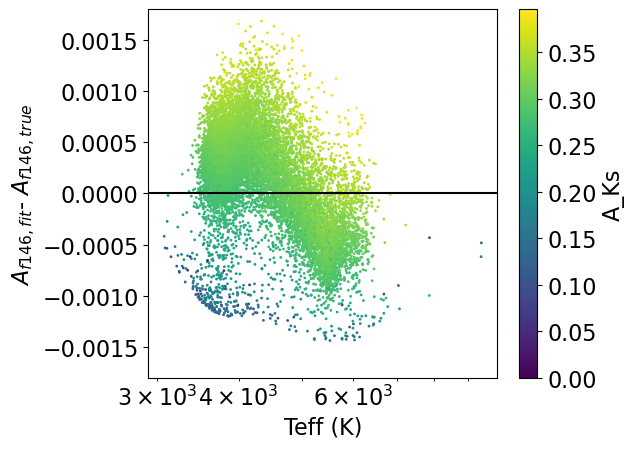

In [20]:
fig = ecf.plot_catalog_results(cat_lb_ext,maglim=25,ext='_lb')
fig.xscale('log')
fig.ylim(-0.0018,0.0018)
fig.savefig('figures/ext_cat_test_f146_lb.png')
fig.savefig('figures/ext_cat_test_f146_lb.pdf', dpi=600)

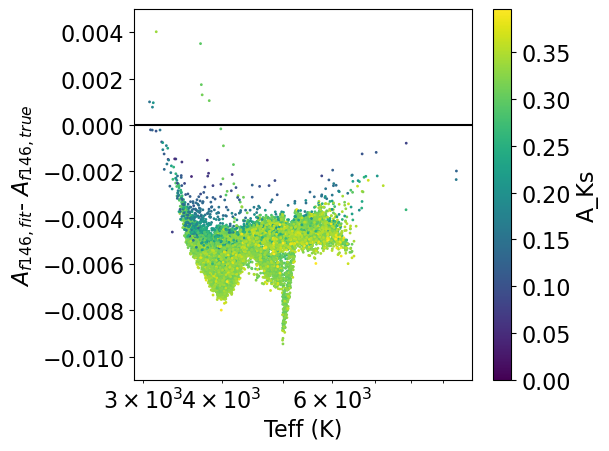

In [21]:
fig = ecf.plot_catalog_results(cat_lb_ext,maglim=25,ext='_lb', use_syn=True)
fig.xscale('log')
plt.ylim(-0.011,0.005)
fig.savefig('figures/ext_cat_test_f146_lb_sp.png')
fig.savefig('figures/ext_cat_test_f146_lb_sp.pdf', dpi=600)

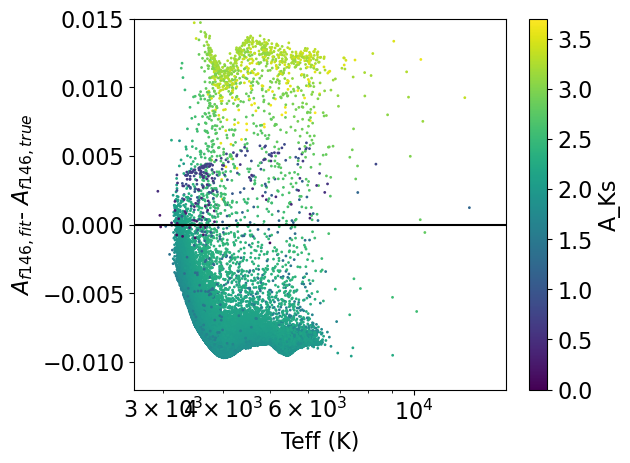

In [22]:
fig = ecf.plot_catalog_results(cat_gc_ext,maglim=25,ext='_gc')
fig.ylim(-0.012,0.015); #fig.xlim(2500,9000)
fig.xscale('log')
fig.savefig('figures/ext_cat_test_f146_gc.png')
fig.savefig('figures/ext_cat_test_f146_gc.pdf', dpi=600)

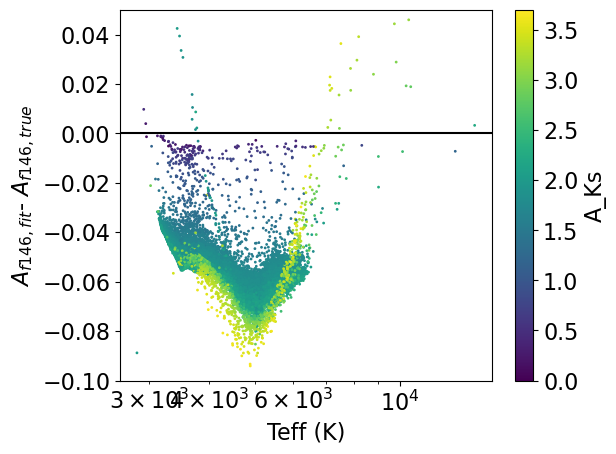

In [23]:
fig = ecf.plot_catalog_results(cat_gc_ext,maglim=25,ext='_gc',use_syn=True)
fig.ylim(-0.1,0.05)
# fig.xlim(2800,8000)
fig.xscale('log')
fig.savefig('figures/ext_cat_test_f146_gc_sp.png')
fig.savefig('figures/ext_cat_test_f146_gc_sp.pdf', dpi=600)

# Euclid

In [24]:
# Set up which colors to use for which fits
euclid_fits = {'euclid_vis': ['roman_wfi_f062-roman_wfi_f087'], 
               'euclid_Y': ['euclid_Y-euclid_J'], 
               'euclid_J': ['euclid_Y-euclid_J','euclid_J-euclid_H'], 
               'euclid_H': ['euclid_J-euclid_H']}

euclid_vis 0.016669341737089435
euclid_Y 0.019623619740994133
euclid_J 0.02335609598185225
euclid_H 0.012577710366529129


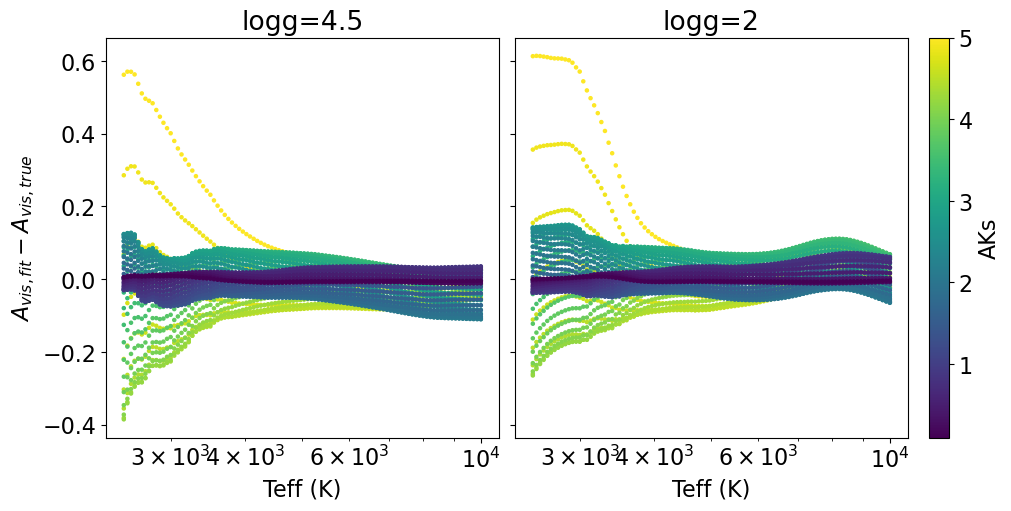

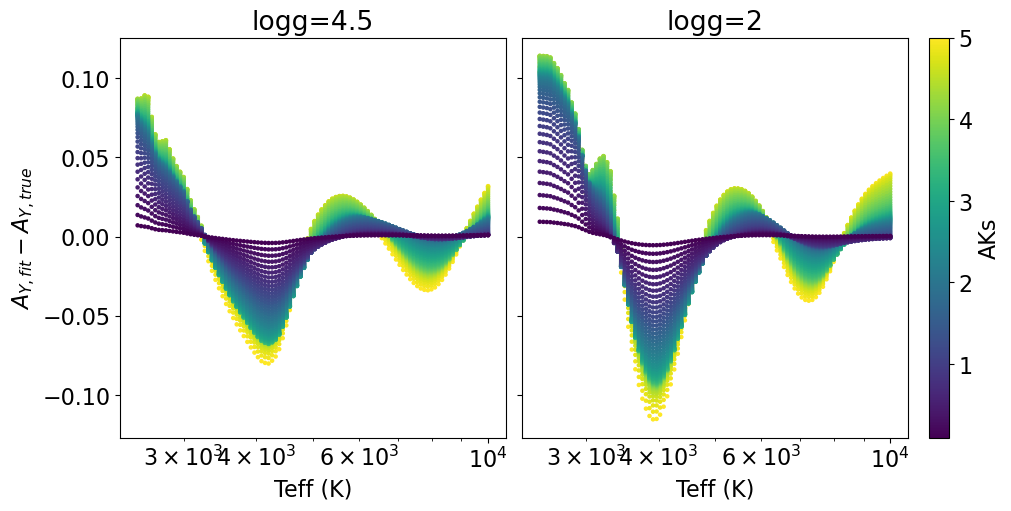

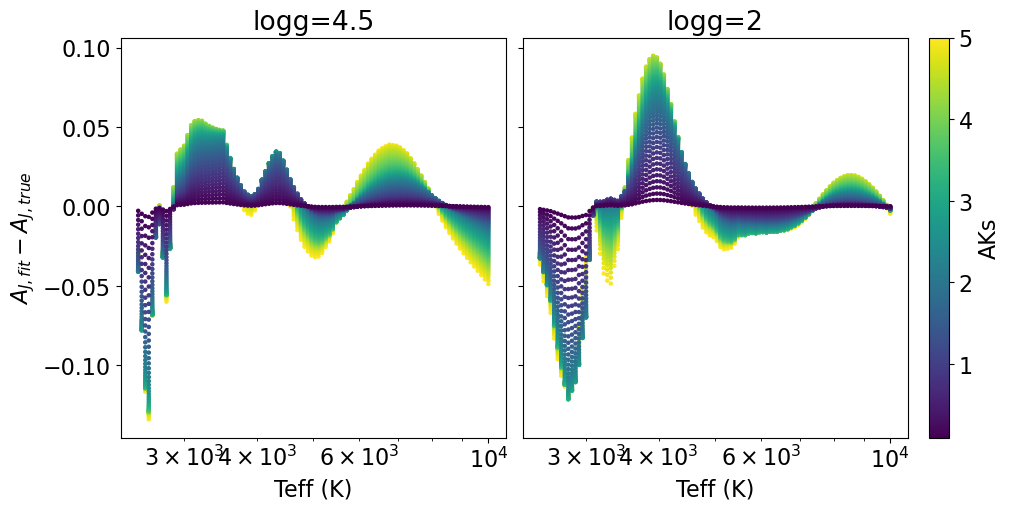

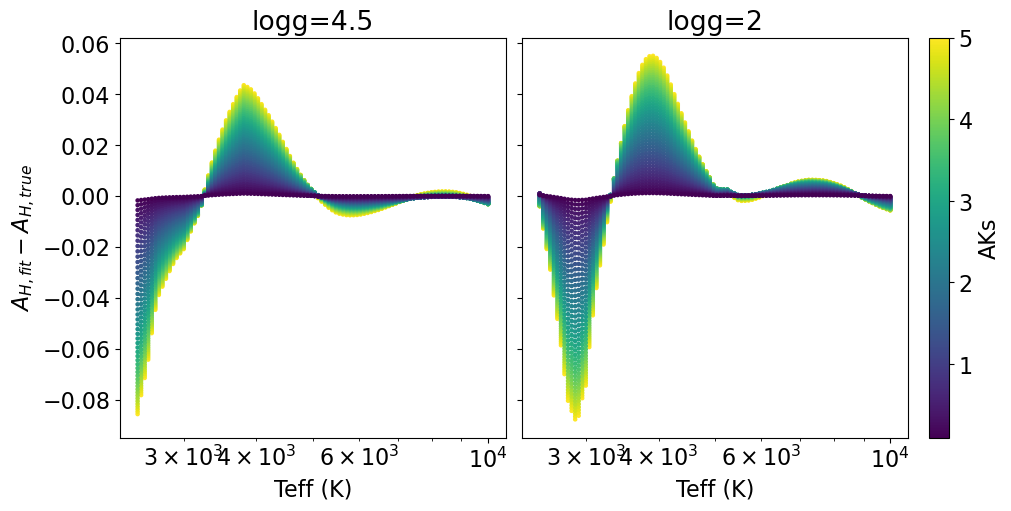

In [25]:
euclid_tabs = []
for k,v in euclid_fits.items():
    cols = []
    for c in v:
        cols.append(f'{c}-abs')
    ecf.run_fit(f'{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    euclid_tabs.append(ecf.print_coeffs_deluxetable())

# DECam

In [26]:
# Set up which colors to use for which fits
decam_fits = {'u': ['u-g', 'g-r', 'r-i'], 
              'g': ['u-g', 'g-r', 'r-i'], 
              'r': ['g-r', 'r-i'], 
              'i': ['r-i', 'i-z'], 
              'z': ['i-z', 'z-Y'],
              'Y': ['z-Y']}

decam_u 0.21069091770924298
decam_g 0.18649921500191827
decam_r 0.07322154126736584
decam_i 0.002748277887821388
decam_z 0.001682170831268572
decam_Y 0.001054345087947203


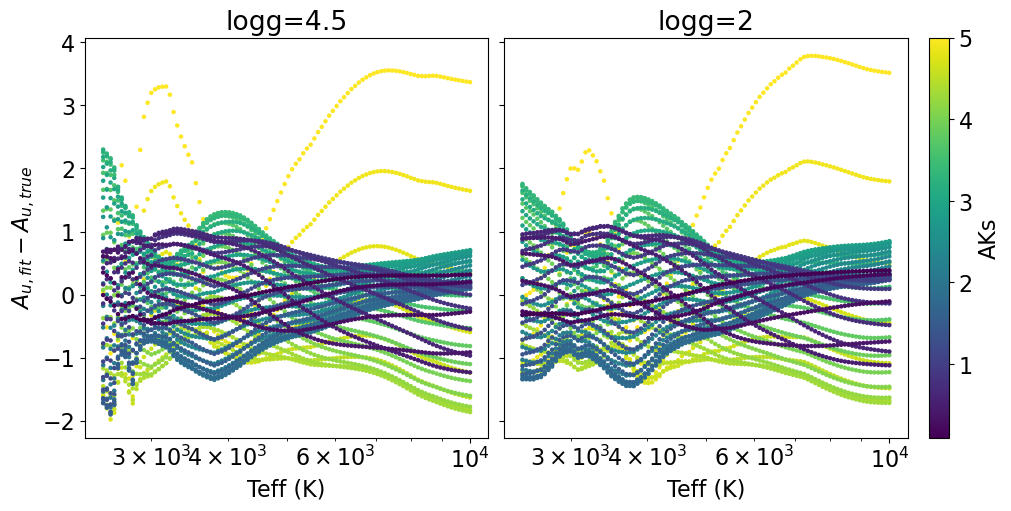

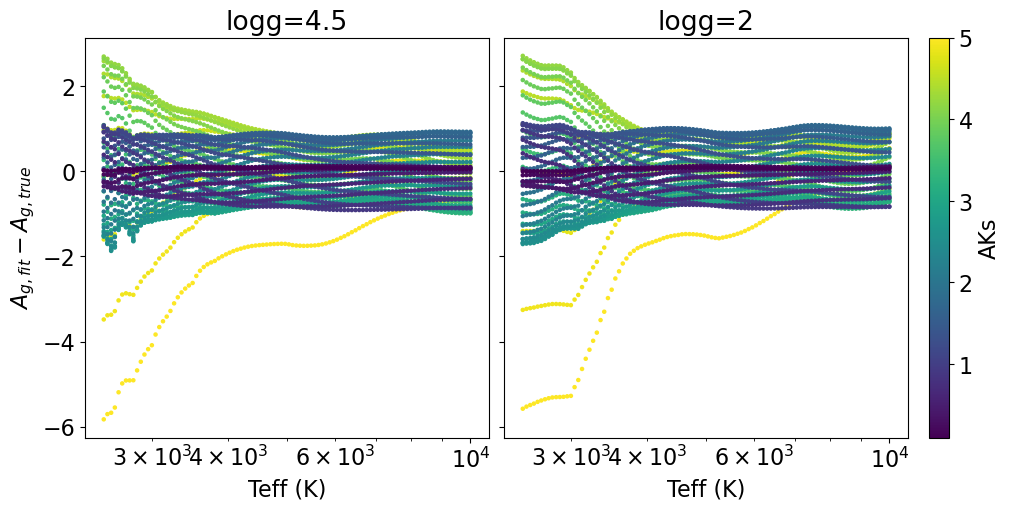

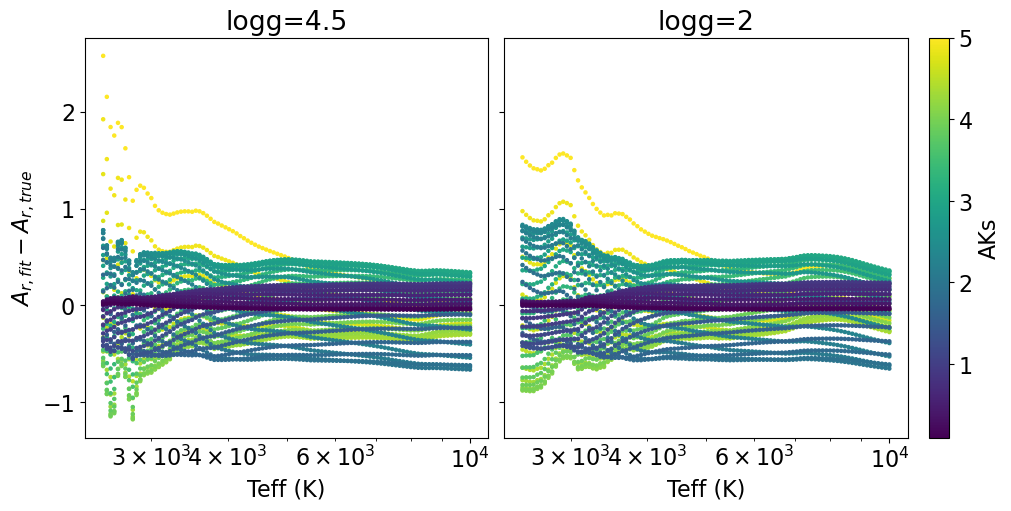

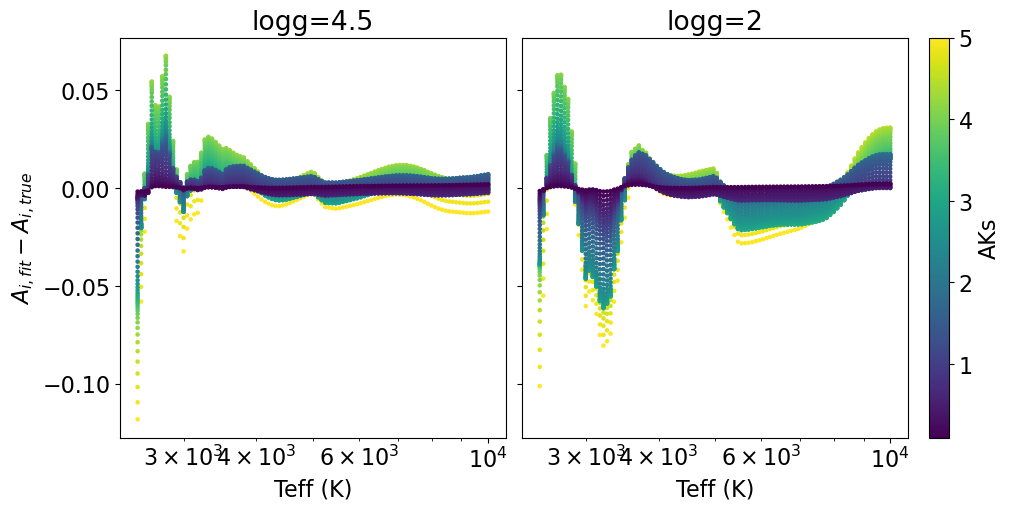

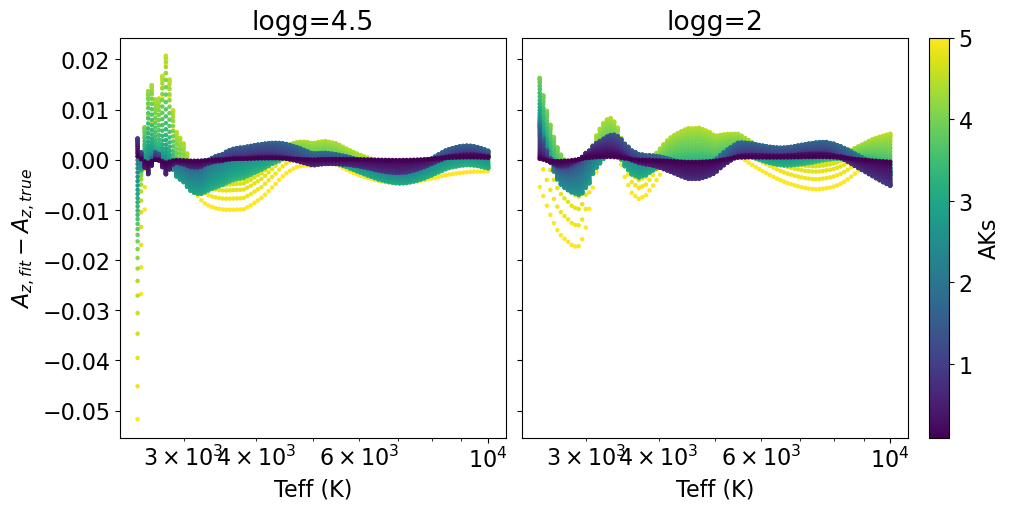

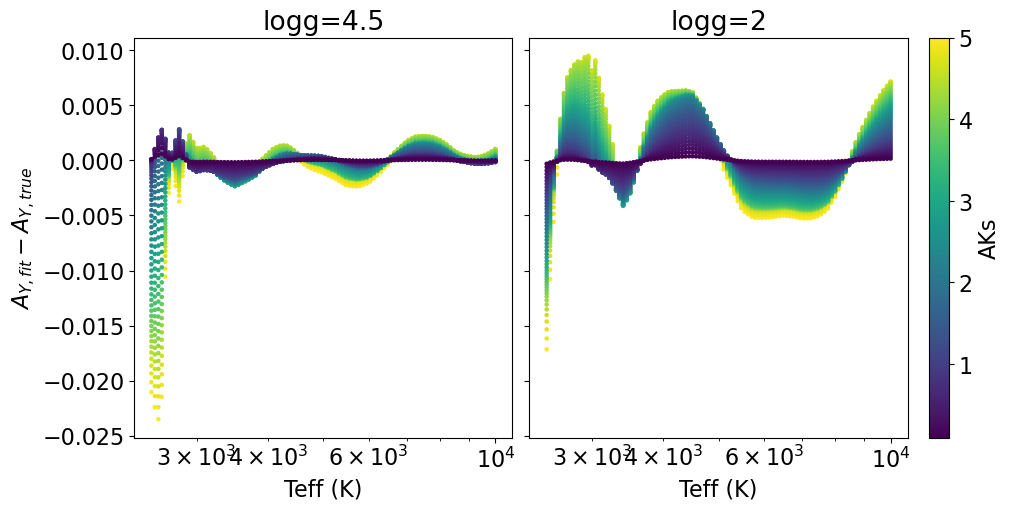

In [27]:
decam_tabs = []
for k,v in decam_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'decam_{c1}-decam_{c2}-abs')
    ecf.run_fit(f'decam_{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    decam_tabs.append(ecf.print_coeffs_deluxetable())

# Gaia

In [28]:
# Set up which colors to use for which fits
gaia_fits = {'G':['G-Gbp','Gbp-Grp'],
             'Gbp':['G-Gbp','Gbp-Grp'],
             'Grp':['G-Gbp','Gbp-Grp']}

gaia_edr3_G 0.04121721311620653
gaia_edr3_Gbp 0.02737648398894244
gaia_edr3_Grp 0.014540845912176508


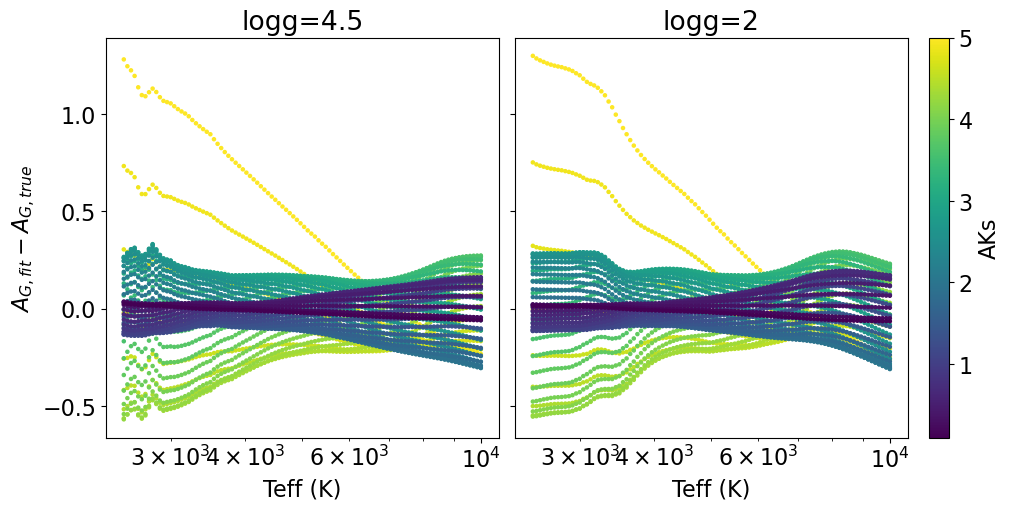

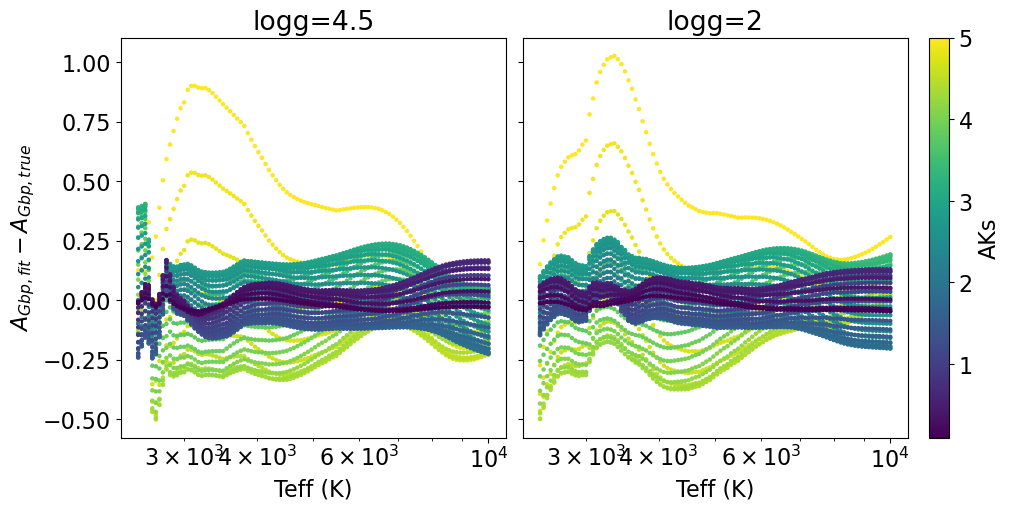

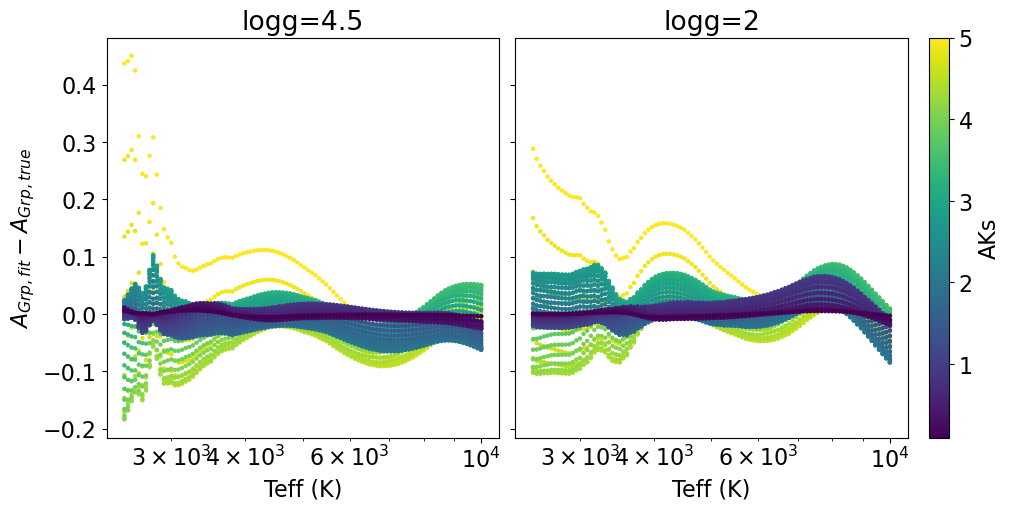

In [29]:
gaia_tabs = []
for k,v in gaia_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'gaia_edr3_{c1}-gaia_edr3_{c2}-abs')
    ecf.run_fit(f'gaia_edr3_{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    gaia_tabs.append(ecf.print_coeffs_deluxetable())

# Rubin

In [30]:
# Set up which colors to use for which fits
rubin_fits = {'u': ['u-g', 'g-r', 'r-i'], 
              'g': ['u-g', 'g-r', 'r-i'], 
              'r': ['g-r', 'r-i'], 
              'i': ['r-i', 'i-z'], 
              'z': ['i-z', 'z-y'],
              'y': ['z-y']}

rubin_u 0.18606565103934333
rubin_g 0.1626357723360319
rubin_r 0.035122864323898766
rubin_i 0.011912307221652365
rubin_z 0.0024048072851061255
rubin_y 0.003980033440531127


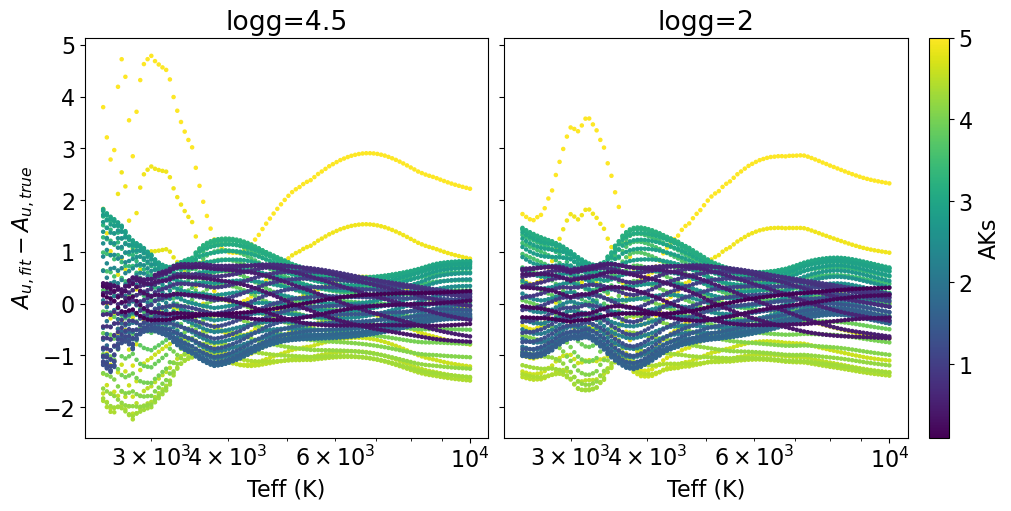

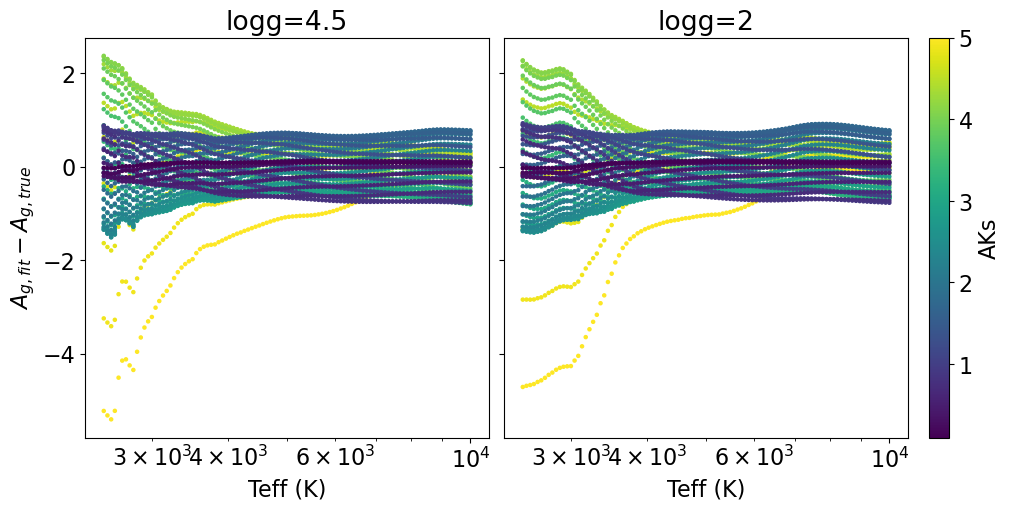

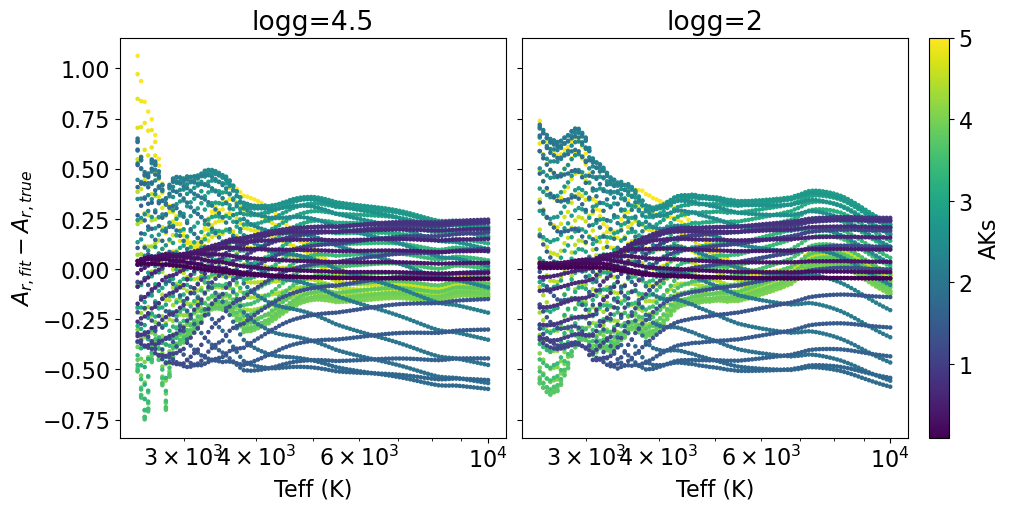

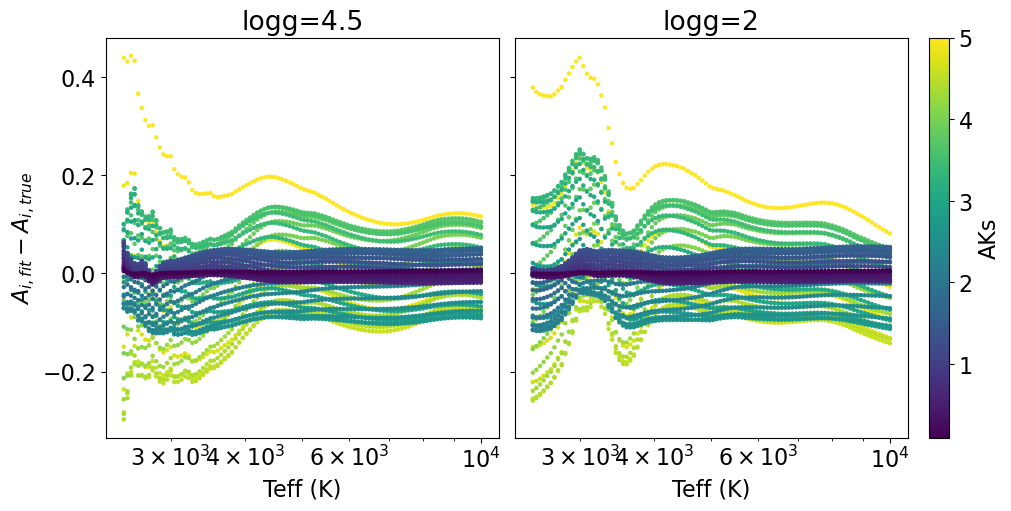

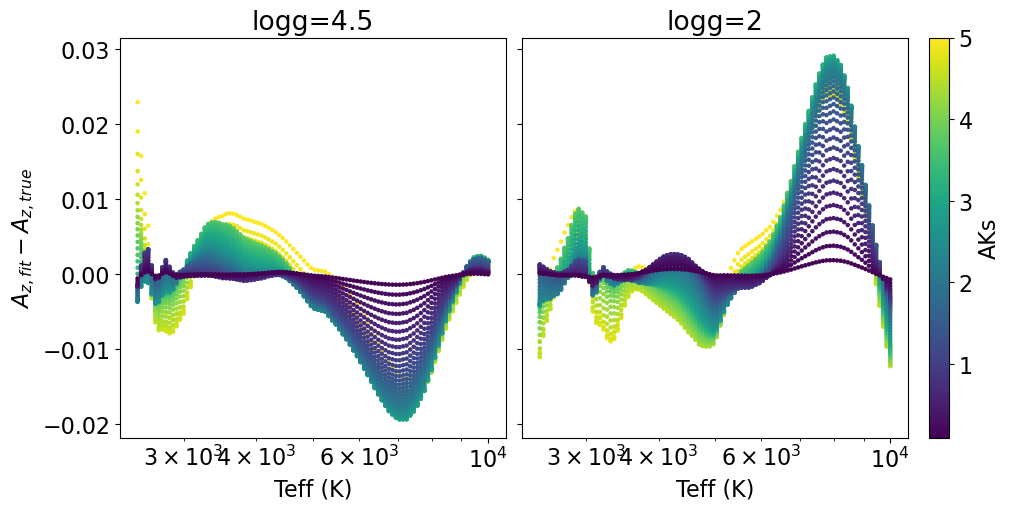

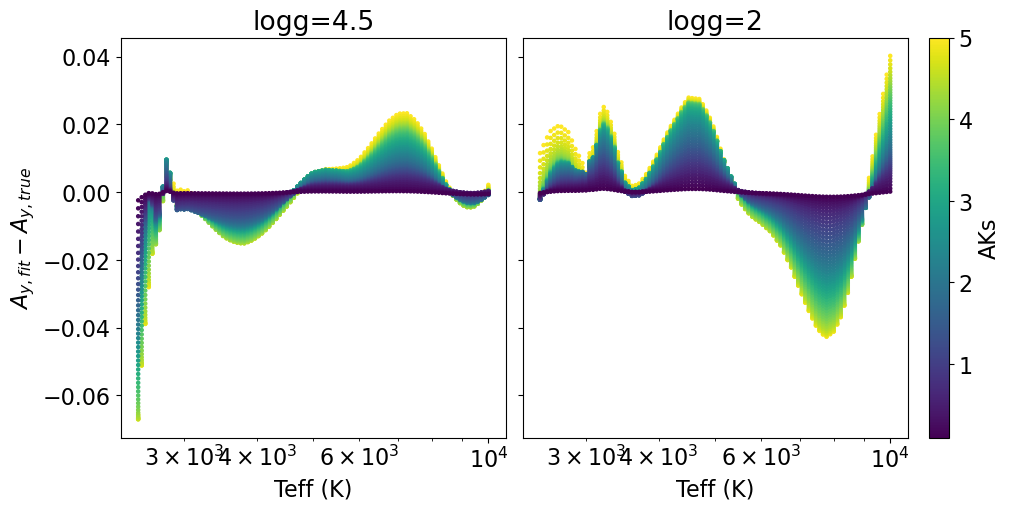

In [31]:
rubin_tabs = []
for k,v in rubin_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'rubin_{c1}-rubin_{c2}-abs')
    ecf.run_fit(f'rubin_{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    rubin_tabs.append(ecf.print_coeffs_deluxetable())

# HST

In [32]:
# Set up which colors to use for which fits
hst_fits = {'wfc3_uvis1_f390w': ['wfc3_uvis1_f390w-wfc3_uvis1_f555w'], # If these first two are bad, bring in f814w
            'wfc3_uvis1_f555w': ['wfc3_uvis1_f390w-wfc3_uvis1_f555w'],
            'wfc3_uvis1_f606w': ['wfc3_uvis1_f606w-wfc3_uvis1_f814w'],
            'wfc3_uvis1_f814w': ['wfc3_uvis1_f606w-wfc3_uvis1_f814w'],
            'wfc3_ir_f098m': ['wfc3_ir_f098m-wfc3_ir_f139m']
           }

wfc3_uvis1_f390w 0.21483547854470877
wfc3_uvis1_f555w 0.22868295083321713
wfc3_uvis1_f606w 0.10053545941646466
wfc3_uvis1_f814w 0.013511774457875167
wfc3_ir_f098m 0.029851719604148345


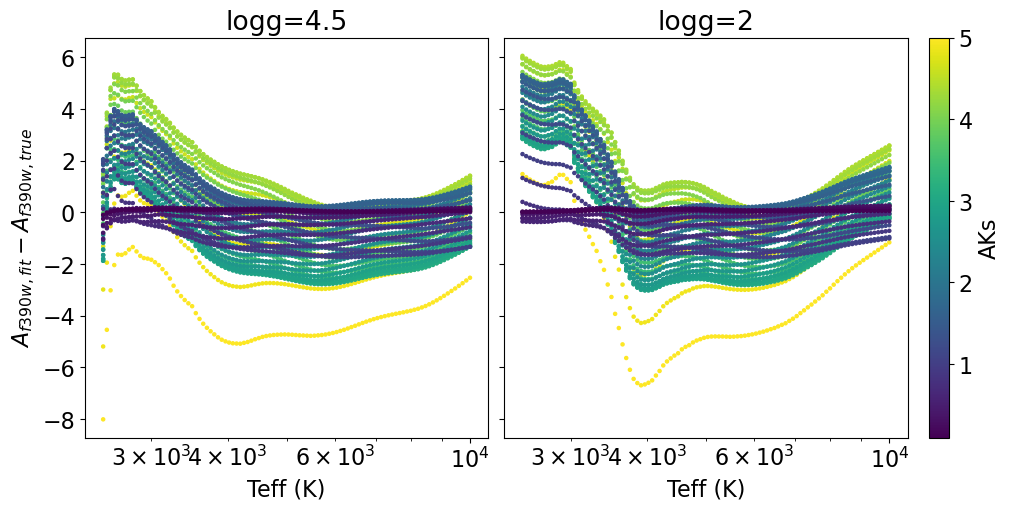

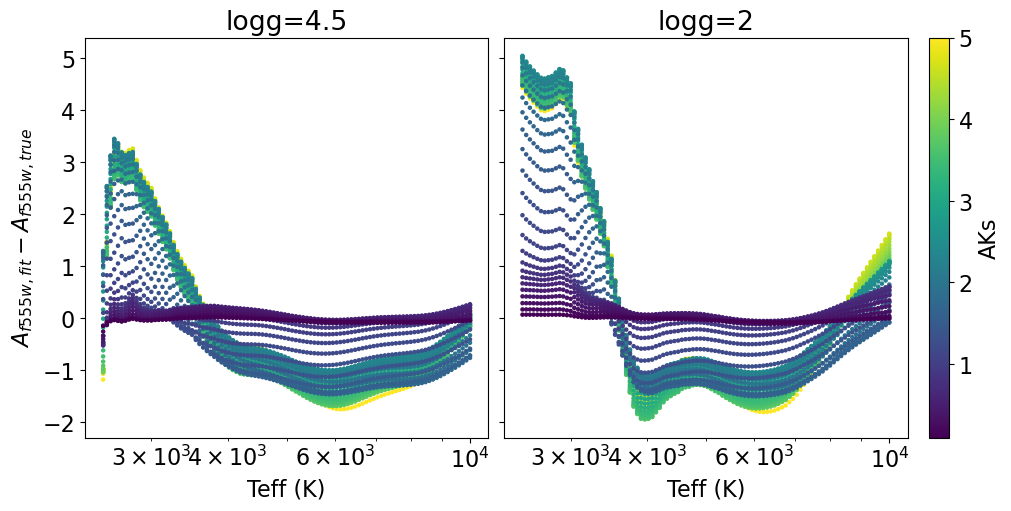

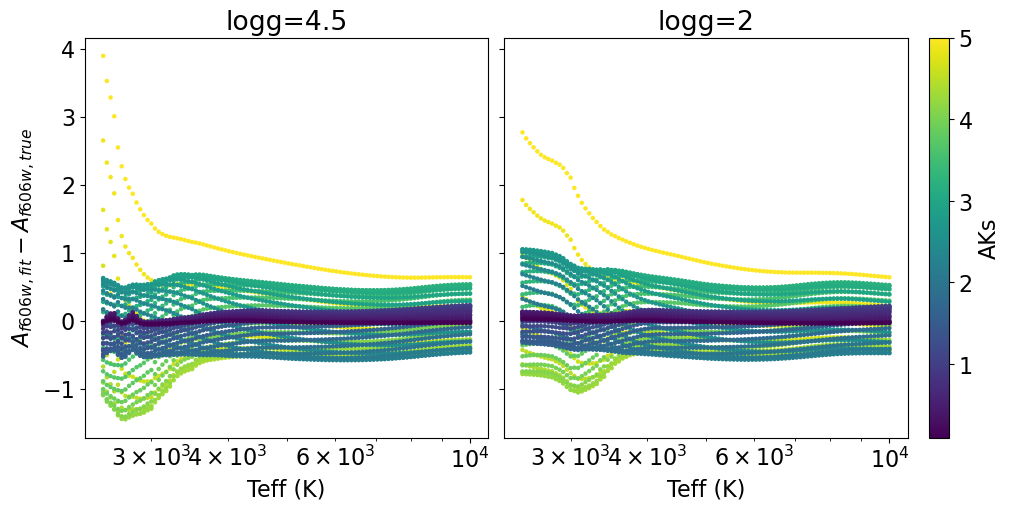

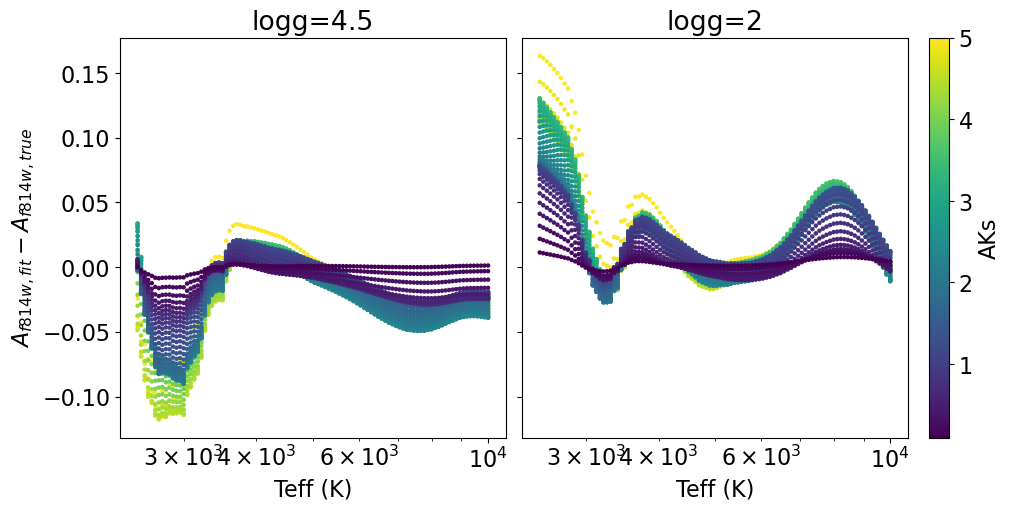

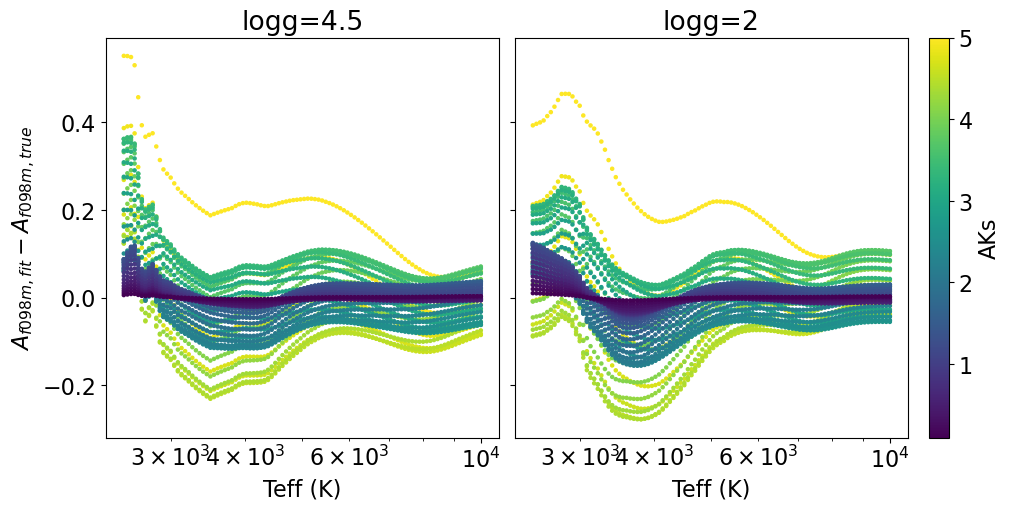

In [33]:
hst_tabs = []
for k,v in hst_fits.items():
    cols = []
    for c in v:
        cols.append(f'{c}-abs')
    ecf.run_fit(f'{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    hst_tabs.append(ecf.print_coeffs_deluxetable())

# JWST

In [34]:
# Set up which colors to use for which fits
jwst_fits = {'f115w': ['f115w-f140m','f140m-f182m'],
           }

jwst_f115w 0.00894115681304868


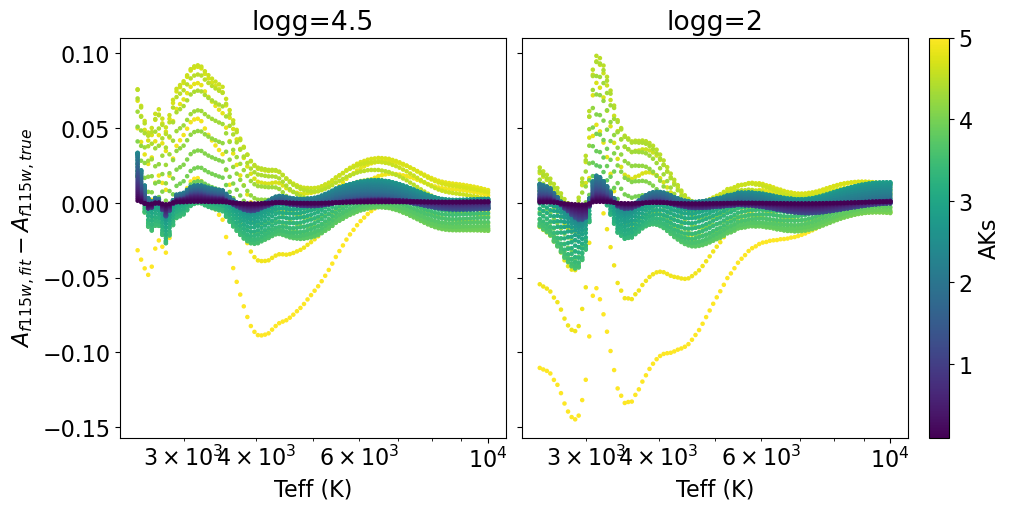

In [35]:
jwst_tabs = []
for k,v in jwst_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'jwst_{c1}-jwst_{c2}-abs')
    ecf.run_fit(f'jwst_{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    jwst_tabs.append(ecf.print_coeffs_deluxetable())

# Generic optical and IR

In [36]:
# Set up which colors to use for which fits
gen_opt_fits = {'U': ['U-B', 'B-V', 'V-R'], 
                'B': ['U-B', 'B-V', 'V-R'], 
                'V': ['B-V', 'V-R'], 
                'R': ['V-R', 'R-I'], 
                'I': ['R-I'], 
           }
gen_ir_fits = {'J': ['J-H'], 
                'H': ['J-H', 'H-K'], 
                'K': ['H-K'], 
           }

bessell_U 0.016727688306769125
bessell_B 0.01968826864457428
bessell_V 0.022179649311621474
bessell_R 0.011000206987889475
bessell_I 0.0060905150116119045
jg_J 0.006219320111929402
jg_H 0.007425572326928243
jg_K 0.010909384670789422


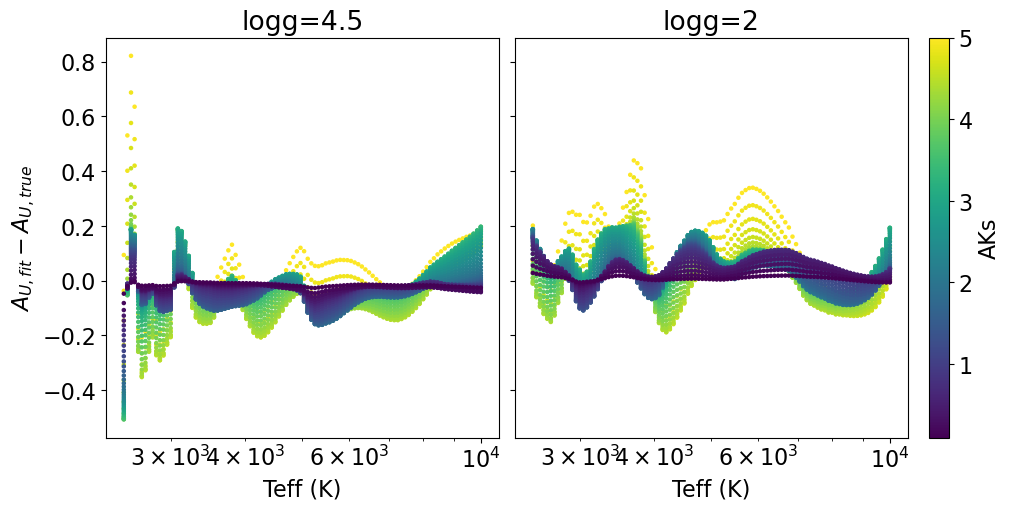

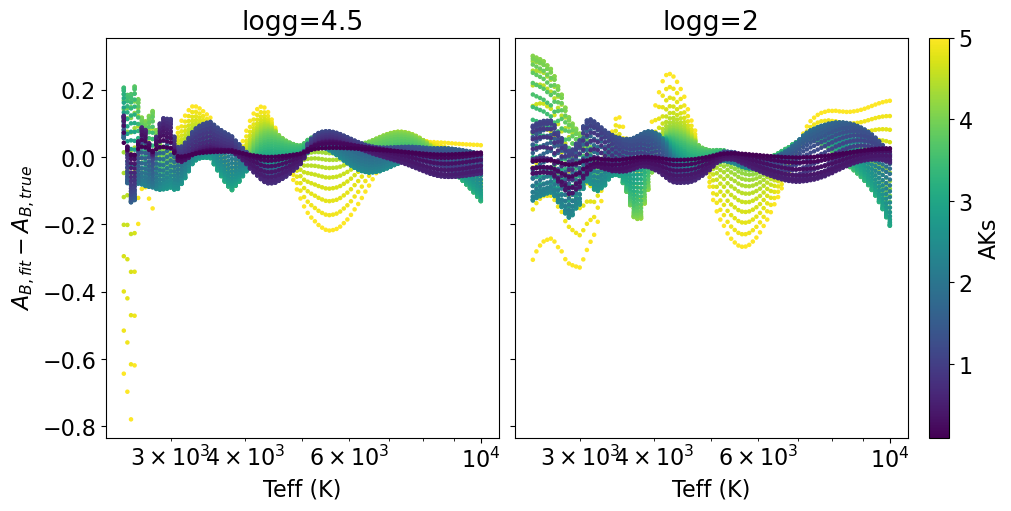

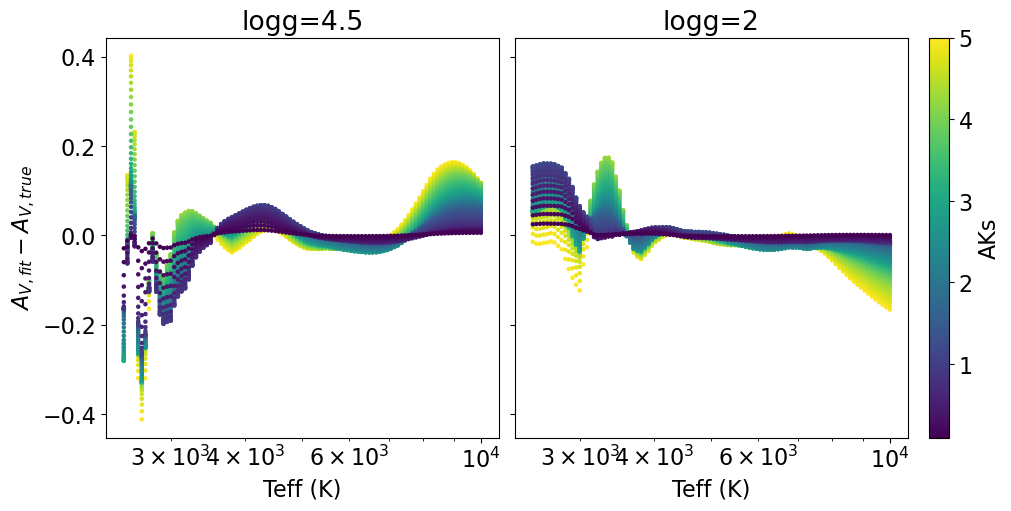

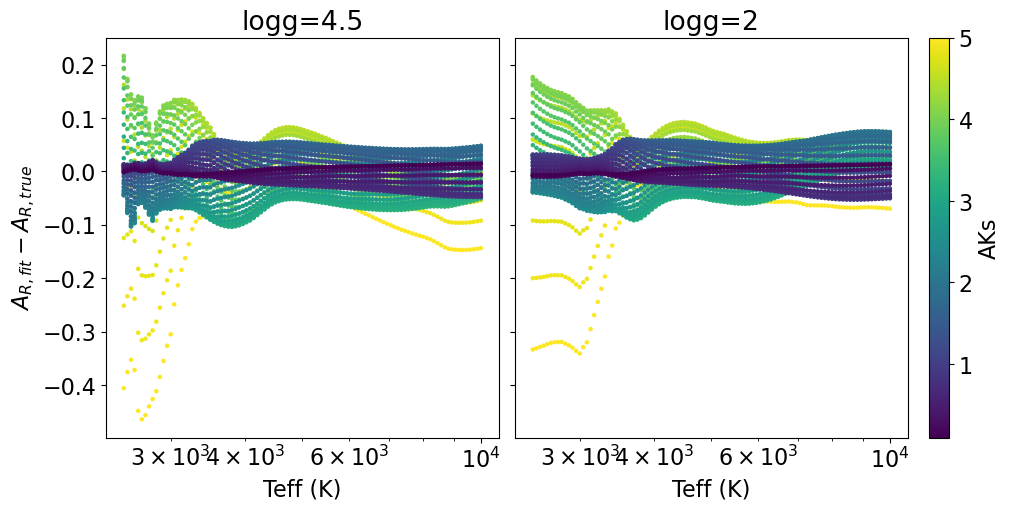

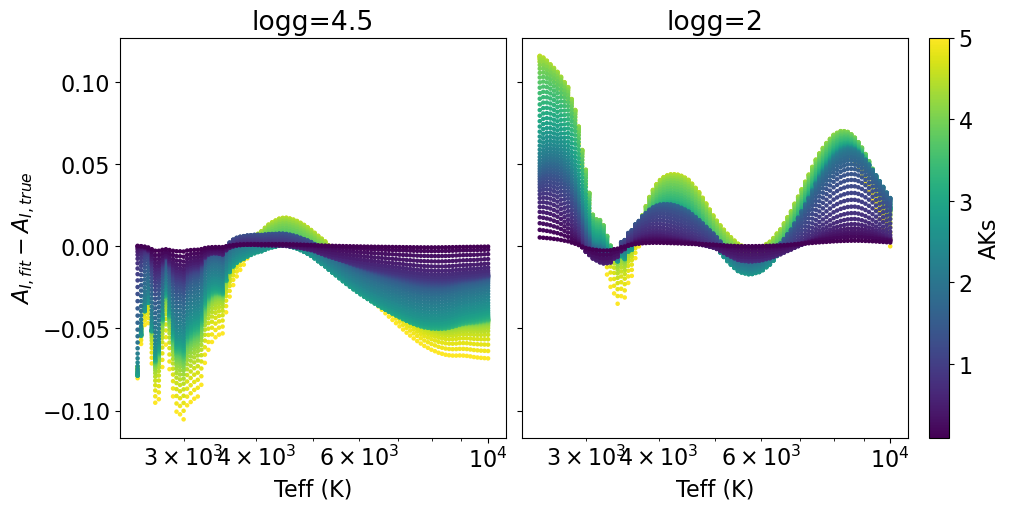

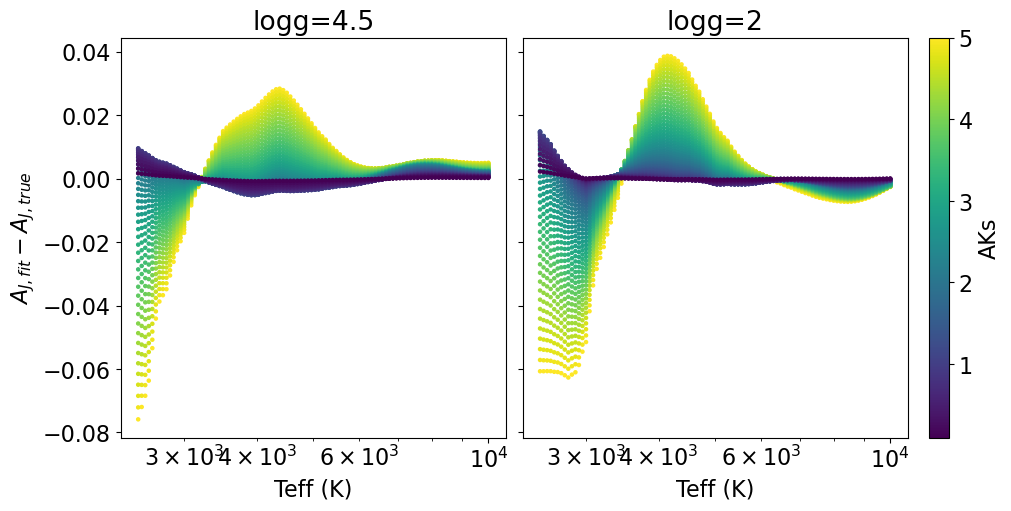

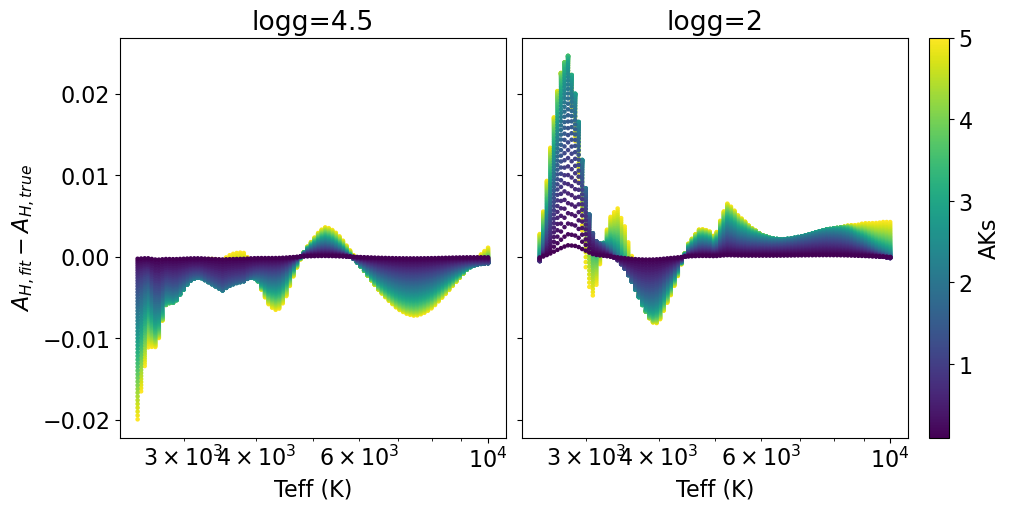

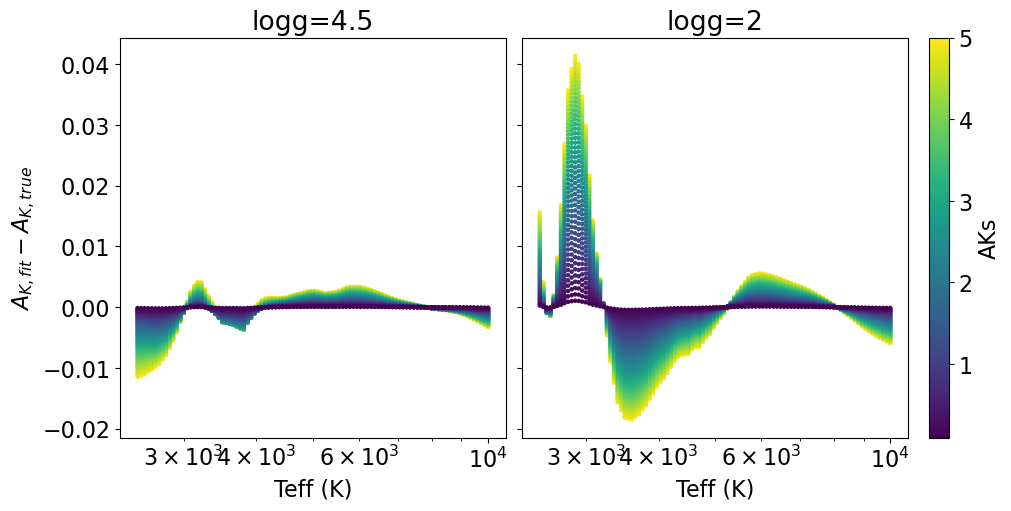

In [37]:
gen_tabs = []
for k,v in gen_opt_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'bessell_{c1}-bessell_{c2}-abs')
    ecf.run_fit(f'bessell_{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    gen_tabs.append(ecf.print_coeffs_deluxetable())
for k,v in gen_ir_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'jg_{c1}-jg_{c2}-abs')
    ecf.run_fit(f'jg_{k}', cols, order=4)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    gen_tabs.append(ecf.print_coeffs_deluxetable())

# OGLE

ogle_V 0.015464693225618192


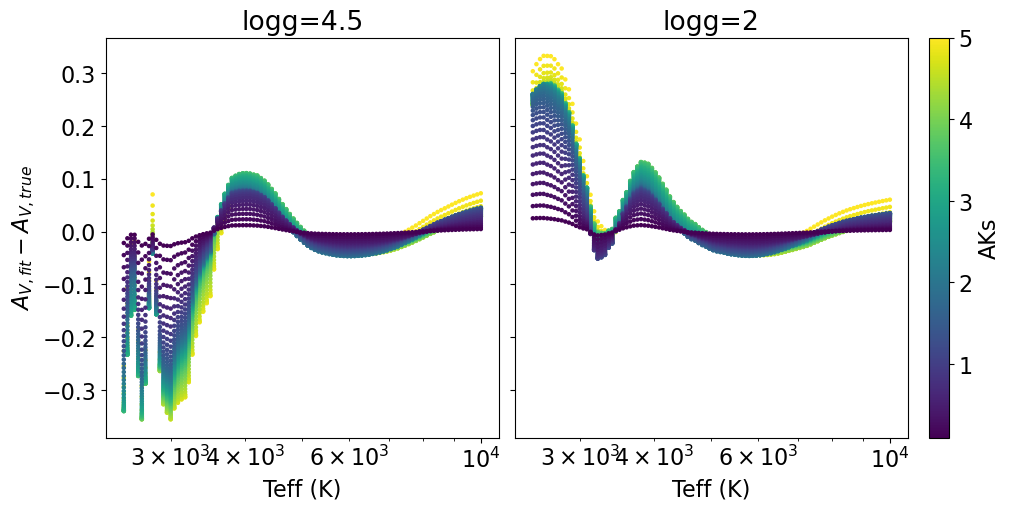

In [38]:
ecf.run_fit(f'ogle_V', ['ogle_V-ogle_I-abs'], order=4)
fits_dict.update(ecf.get_fit_dict())
ecf.plot_fit_result()
ogle_tab = ecf.print_coeffs_deluxetable()

ogle_I 0.003947386622458373


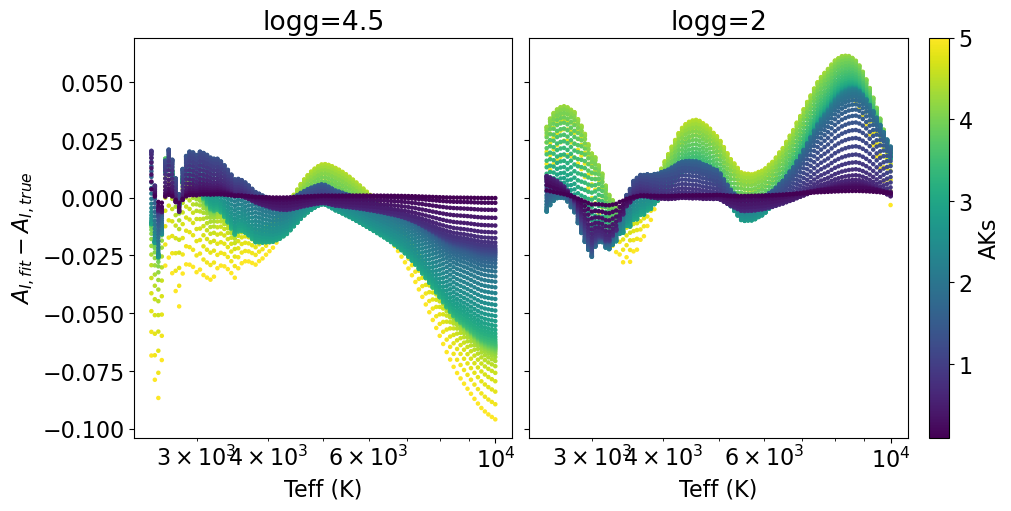

In [39]:
ecf.run_fit(f'ogle_I', ['ogle_V-ogle_I-abs'], order=4)
fits_dict.update(ecf.get_fit_dict())
ecf.plot_fit_result()
ogle_tab = ecf.print_coeffs_deluxetable()

ogle_Rw 0.020851003138825198


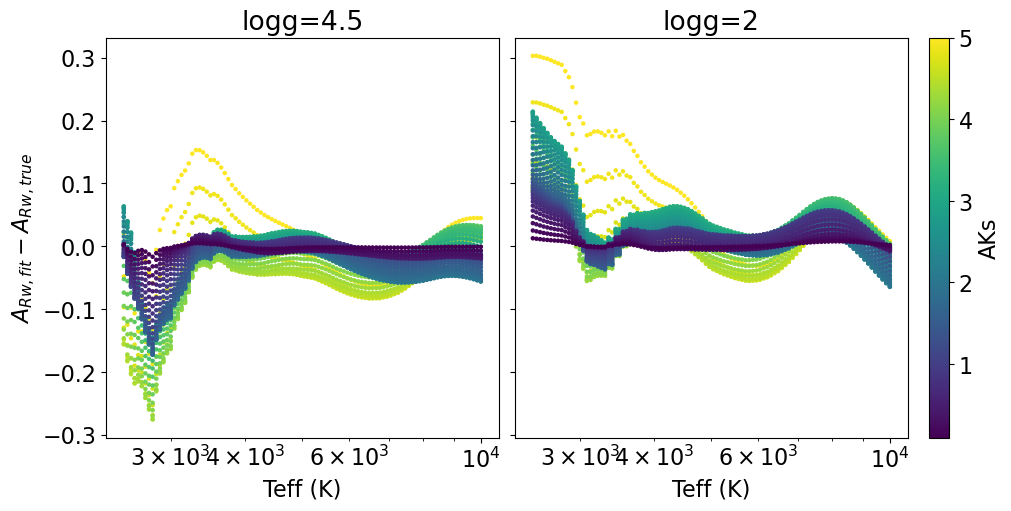

In [40]:
ecf.run_fit(f'ogle_Rw', ['ogle_V-ogle_I-abs'], order=4)
fits_dict.update(ecf.get_fit_dict())
ecf.plot_fit_result()
ogle_tab = ecf.print_coeffs_deluxetable()

# Save results

In [45]:
with open("../ext_coeffs_absmag_AKs5.json", "w") as f:
    json.dump(fits_dict, f, indent=4)

In [42]:
ecf.make_mag_conversion_json()

For roman,wfi,f062, m_st - m_vega = 0.4485655513149185 mag(ST / VEGA)
For roman,wfi,f087, m_st - m_vega = 1.5011306617393418 mag(ST / VEGA)
For roman,wfi,f106, m_st - m_vega = 2.091069240236887 mag(ST / VEGA)
For roman,wfi,f129, m_st - m_vega = 2.8331118284739136 mag(ST / VEGA)
For roman,wfi,f158, m_st - m_vega = 3.598640444534609 mag(ST / VEGA)
For roman,wfi,f184, m_st - m_vega = 4.202554323134333 mag(ST / VEGA)
For roman,wfi,f213, m_st - m_vega = 4.768357921984802 mag(ST / VEGA)
For roman,wfi,f146, m_st - m_vega = 3.1328608780094047 mag(ST / VEGA)
For euclid,Y, m_st - m_vega = 2.1639904456147754 mag(ST / VEGA)
For euclid,J, m_st - m_vega = 3.036218779282924 mag(ST / VEGA)
For euclid,H, m_st - m_vega = 4.032237957708368 mag(ST / VEGA)
For decam,u, m_st - m_vega = -0.16838579754051192 mag(ST / VEGA)
For decam,g, m_st - m_vega = -0.4368935378430456 mag(ST / VEGA)
For decam,r, m_st - m_vega = 0.5214262041110116 mag(ST / VEGA)
For decam,i, m_st - m_vega = 1.1943558464399056 mag(ST / VEGA)

In [43]:
tab = ecf.save_all_coeffs_machine_readable(fits_dict, 'test_mrt2.dat')

In [44]:
tab.meta

{}